In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
games=pd.read_csv('metacritic_games.csv')

In [3]:
games.head(1)

,game,platform,developer,genre,number_players,rating,release_date,positive_critics,neutral_critics,negative_critics,positive_users,neutral_users,negative_users,metascore,user_score
0,Portal 2,PC,Valve Software,Action,NaN,E10+,"Apr 18, 2011",51,1,0,1700,107,19,95,90


# Convert date to date/time #

In [4]:
games['release_date'] = pd.to_datetime(games['release_date'])

In [5]:
games['release_year'] = games['release_date'].dt.year

games['release_month'] = games['release_date'].dt.month

In [6]:
games.head(1)

,game,platform,developer,genre,number_players,rating,release_date,positive_critics,neutral_critics,negative_critics,positive_users,neutral_users,negative_users,metascore,user_score,release_year,release_month
0,Portal 2,PC,Valve Software,Action,NaN,E10+,2011-04-18,51,1,0,1700,107,19,95,90,2011,4


# Average Critic and User Scores by Year #

In [8]:
yearly_summary = (
    games.groupby('release_year', as_index=False)[['metascore', 'user_score']].mean()).round(2)
yearly_summary

,release_year,metascore,user_score
0,2011,68.51,65.38
1,2012,70.08,68.45
2,2013,70.93,68.85
3,2014,71.93,68.61
4,2015,71.77,67.68
5,2016,71.73,66.86
6,2017,72.82,66.80
7,2018,72.60,66.27
8,2019,74.44,62.94


# Releases by Year #

In [10]:
yearly_releases = (
    games
    .groupby('release_year', as_index=False)
    .size()
    .rename(columns={'size': 'game_count'})
)

yearly_releases

,release_year,game_count
0,2011,270
1,2012,373
2,2013,473
3,2014,645
4,2015,829
5,2016,939
6,2017,981
7,2018,1011
8,2019,178


# Releases by Year (Visualization) #

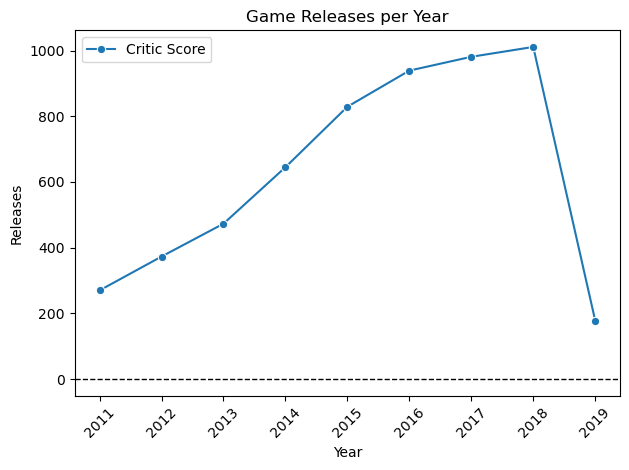

In [12]:
sns.lineplot(data=yearly_releases, x='release_year', y='game_count', marker='o', label='Critic Score')

plt.title('Game Releases per Year')
plt.xlabel('Year')
plt.ylabel('Releases')
plt.xticks(rotation=45)  

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

# Average Critic and User Scores by Year #

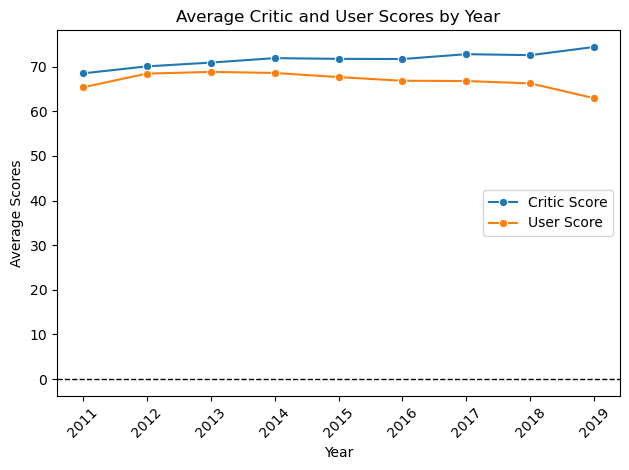

In [13]:
sns.lineplot(data=yearly_summary, x='release_year', y='metascore', marker='o', label='Critic Score')

sns.lineplot(data=yearly_summary, x='release_year', y='user_score', marker='o', label='User Score')

plt.title('Average Critic and User Scores by Year')
plt.xlabel('Year')
plt.ylabel('Average Scores')
plt.xticks(rotation=45)  

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig("average_user_vs_critic")
plt.show()

# Redefining Genres of Select Games #

In [14]:
games.loc[games['game'] == 'Mario Kart 8 Deluxe', 'genre'] = 'Racing'

games.loc[games['game'] == 'The Walking Dead: A Telltale Games Series', 'genre'] = 'Horror'

games.loc[games['game'] == 'Cities: Skylines', 'genre'] = 'Simulation'

games.loc[games['game'] == 'Deadpool', 'genre'] = 'Action Adventure'

games.loc[games['game'] == "Super Lucky's Tale", 'genre'] = 'Platformer'

games.loc[games['game'] == "Rad Rodgers", 'genre'] = 'Action'

games.loc[games['game'] == "Dragon Quest Heroes: The World Tree's Woe and the Blight Below", 'genre'] = 'Action'

games.loc[games['game'] == "The Sims 4", 'genre'] = 'Simulation'

games.loc[games['game'] == 'Call of Duty: Modern Warfare Remastered', 'genre'] = 'Shooter'

games.loc[games['genre'] == 'Sim', 'genre'] = 'Sports'

games.loc[games['genre'] == 'Breeding/Constructing', 'genre'] = 'Simulation'

games.loc[games['genre'] == 'WWI', 'genre'] = 'Simulation'

games.loc[games['genre'] == 'Edutainment', 'genre'] = 'Puzzle'

games.loc[games['genre'] == 'Tycoon', 'genre'] = 'Simulation'

In [15]:
games.loc[games['genre'] == 'Arcade', 'genre'] = 'Sports'

games.loc[games['genre'] == 'Alternative', 'genre'] = 'Sports'

games.loc[games['game'] == 'Tales of Berseria', 'genre'] = 'Action RPG'

games.loc[games['game'] == 'Yo-kai Watch', 'genre'] = 'Console-style RPG'

games.loc[games['genre'] == 'Turn-Based', 'genre'] = 'Strategy'

games.loc[games['game'] == 'Broken Age', 'genre'] = 'Adventure'

games.loc[games['game'] == 'LawBreakers', 'genre'] = 'Shooter'

games.loc[games['game'] == 'Affordable Space Adventures', 'genre'] = 'Puzzle'

games.loc[games['genre'] == 'Scrolling', 'genre'] = 'Shooter'

In [16]:
games['genre'].value_counts().nsmallest(20)

genre
MOBA                             1
Tactical                         1
Music                            1
Formula One                      1
Rally / Offroad                  1
Beat-'Em-Up                      1
Party                            2
Military                         2
Card Battle                      2
Fighting                         2
Massively Multiplayer Online     5
GT / Street                      5
PC-style RPG                     6
Console-style RPG                7
Traditional                      8
First-Person                    13
Historic                        18
Platformer                      25
Horror                          26
Action RPG                      27
Name: count, dtype: int64

C:\Users\djbel\AppData\Local\Temp\ipykernel_6292\4167993621.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


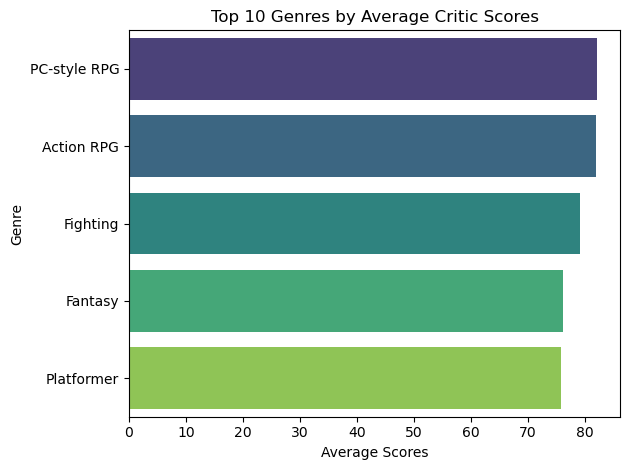

In [17]:
excluded_genres = ['General', 'Music', 'Card Battle', 'Military']

top_genres_meta = (
    games[~games['genre'].isin(excluded_genres)]
        .groupby('genre', as_index=False)['metascore']
        .mean()
        .sort_values(by='metascore', ascending=False)
        .head(5)
)

sns.barplot(
    data=top_genres_meta,
    x='metascore',
    y='genre',
    palette='viridis'
)

plt.title('Top 10 Genres by Average Critic Scores')
plt.xlabel('Average Scores')
plt.ylabel('Genre')

plt.tight_layout()
plt.savefig("critic_genre")
plt.show()

C:\Users\djbel\AppData\Local\Temp\ipykernel_6292\664385888.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


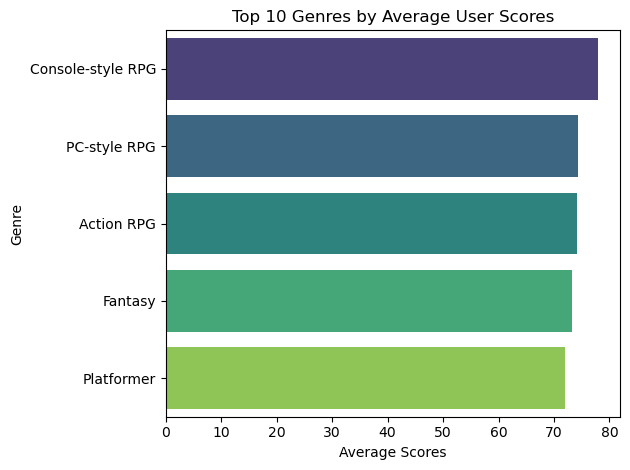

In [18]:
top_genres_user = (
    games[~games['genre'].isin(excluded_genres)]
        .groupby('genre', as_index=False)['user_score']
        .mean()
        .sort_values(by='user_score', ascending=False)
        .head(5)
)
sns.barplot(
    data=top_genres_user,
    x='user_score',
    y='genre',
    palette='viridis'
)

plt.title('Top 10 Genres by Average User Scores')
plt.xlabel('Average Scores')
plt.ylabel('Genre')

plt.tight_layout()
plt.savefig("user_genre")
plt.show()

C:\Users\djbel\AppData\Local\Temp\ipykernel_6292\1894356393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


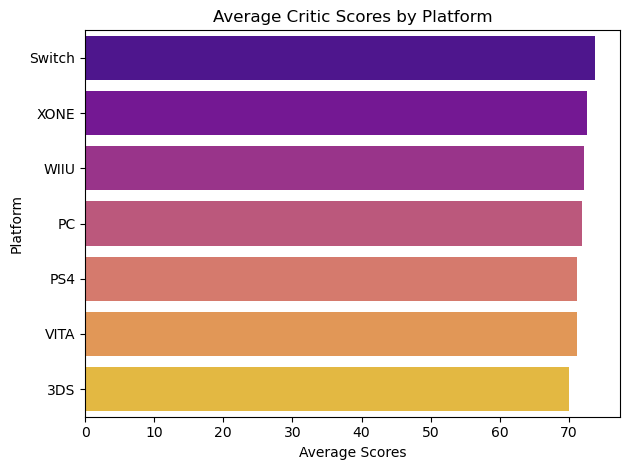

In [19]:
top_platforms_meta = (games.groupby('platform', as_index=False)['metascore'].mean().sort_values(by='metascore', ascending=False))

sns.barplot(
    data=top_platforms_meta,
    x='metascore',
    y='platform',
    palette='plasma'
)

plt.title('Average Critic Scores by Platform')
plt.xlabel('Average Scores')
plt.ylabel('Platform')

plt.tight_layout()
plt.savefig("critic_platform")
plt.show()

C:\Users\djbel\AppData\Local\Temp\ipykernel_6292\705932818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


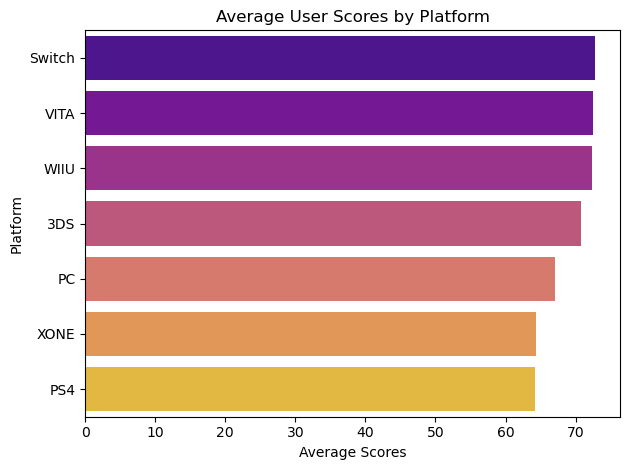

In [20]:
top_platforms_user = (games.groupby('platform', as_index=False)['user_score'].mean().sort_values(by='user_score', ascending=False))

sns.barplot(
    data=top_platforms_user,
    x='user_score',
    y='platform',
    palette='plasma'
)

plt.title('Average User Scores by Platform')
plt.xlabel('Average Scores')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

C:\Users\djbel\AppData\Local\Temp\ipykernel_6292\1259413921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


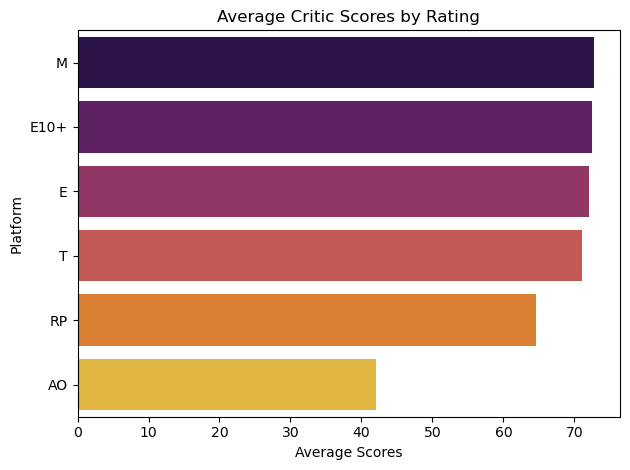

In [21]:
top_ratings_meta = (games.groupby('rating', as_index=False)['metascore'].mean().sort_values(by='metascore', ascending=False))

sns.barplot(
    data=top_ratings_meta,
    x='metascore',
    y='rating',
    palette='inferno'
)

plt.title('Average Critic Scores by Rating')
plt.xlabel('Average Scores')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

C:\Users\djbel\AppData\Local\Temp\ipykernel_6292\2391288400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


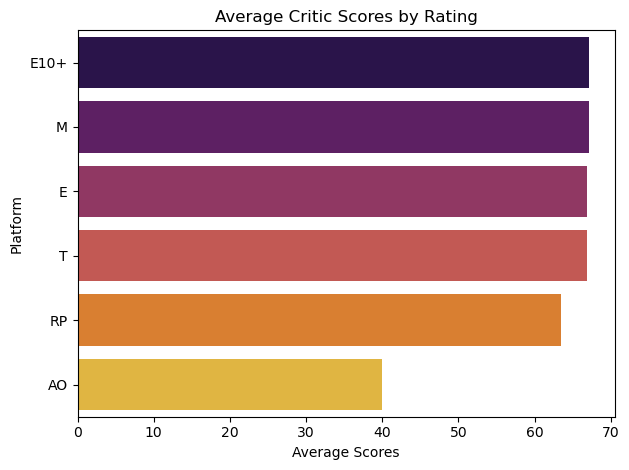

In [22]:
top_ratings_user = (games.groupby('rating', as_index=False)['user_score'].mean().sort_values(by='user_score', ascending=False))

sns.barplot(
    data=top_ratings_user,
    x='user_score',
    y='rating',
    palette='inferno'
)

plt.title('Average Critic Scores by Rating')
plt.xlabel('Average Scores')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

# Correlation/Scatterplot #

In [23]:
corr = games[['metascore', 'user_score']].corr()
print(corr)

            metascore  user_score
metascore    1.000000    0.550555
user_score   0.550555    1.000000


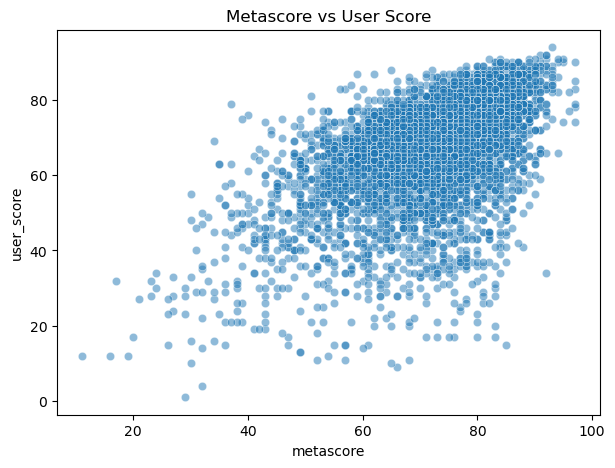

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=games,
    x='metascore',
    y='user_score',
    alpha=0.5
)
plt.title("Metascore vs User Score")
plt.show()

# Games with High User Scores and Low Critic Scores #

In [26]:
games['score_gap'] = games['user_score'] - games['metascore']

In [27]:
games[['game', 'genre', 'platform', 'metascore', 'user_score', 'score_gap']] \
    .sort_values('score_gap', ascending=False) \
    .head(10)

,game,genre,platform,metascore,user_score,score_gap
5698,Left Alive,Action Adventure,PS4,37,79,42
5504,Senran Kagura Reflexions,Action,Switch,39,75,36
1105,The Chaos Engine (2013),Action,PC,40,76,36
5514,Past Cure,Action,XONE,34,69,35
3510,Dead or Alive Xtreme 3: Fortune,Sports,PS4,43,74,31
5470,Immortal: Unchained,Role-Playing,XONE,51,81,30
4486,Inmates,Action Adventure,PC,46,75,29
4425,Final Fantasy XV: Episode Gladiolus,Role-Playing,PS4,59,87,28
626,Cortex Command,Action,PC,44,72,28
5513,Super Seducer: How to Talk to Girls,Adventure,PC,35,63,28


# Games with High Critic Scores and Low User Scores #

In [29]:
games['abs_score_gap'] = games['score_gap'].abs()

games[['game', 'genre', 'platform', 'metascore', 'user_score', 'abs_score_gap']] \
    .sort_values('abs_score_gap', ascending=False) \
    .head(10)

,game,genre,platform,metascore,user_score,abs_score_gap
3616,NBA 2K18,Sports,XONE,85,15,70
4659,FIFA 19,Sports,PS4,83,17,66
3751,NBA 2K18,Sports,PS4,80,17,63
4665,FIFA 19,Sports,XONE,83,20,63
751,Company of Heroes 2,Strategy,PC,80,21,59
3940,Call of Duty: Infinite Warfare - Sabotage,Action,PS4,76,17,59
2592,Out of the Park Baseball 17,Sports,PC,92,34,58
4007,Chime Sharp,Puzzle,XONE,75,17,58
4767,Madden NFL 19,Sports,PS4,80,23,57
4244,Star Wars Battlefront II,Action,PS4,68,11,57


# Average Critic-User Disagreement by Genre #

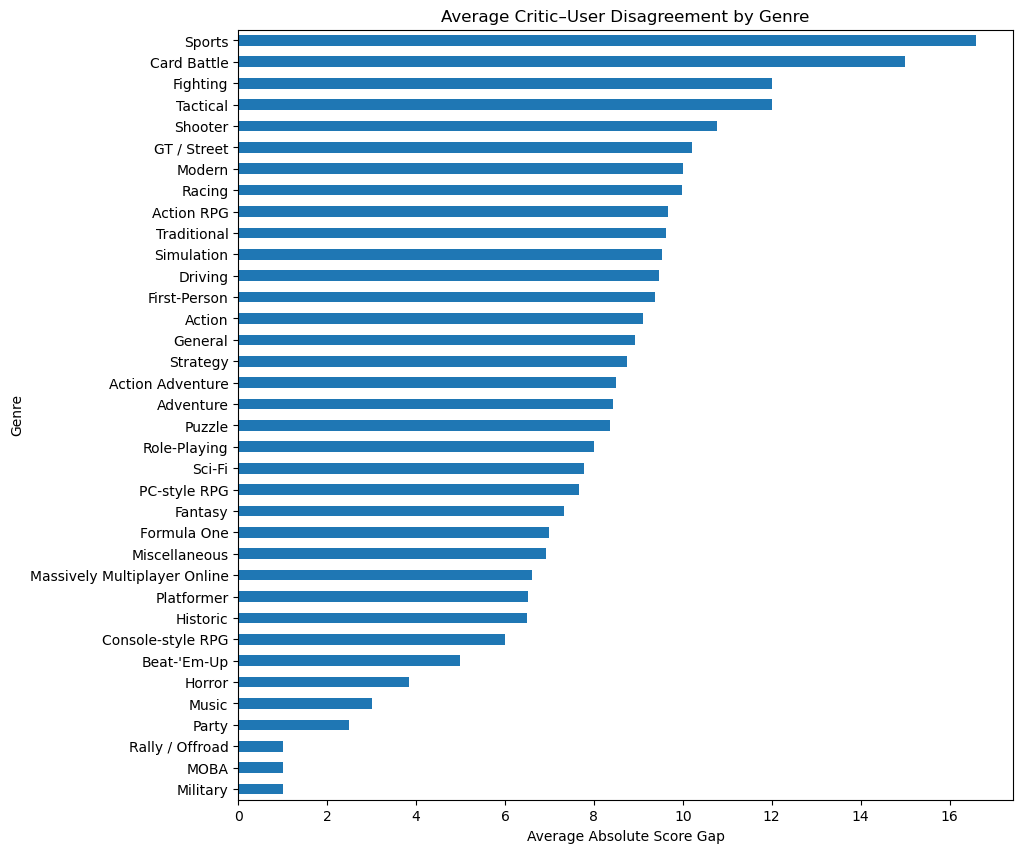

In [30]:
genre_gap = (
    games.groupby('genre')['abs_score_gap']
      .mean()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10,10))
genre_gap.plot(kind='barh')
plt.title("Average Critic–User Disagreement by Genre")
plt.xlabel("Average Absolute Score Gap")
plt.ylabel("Genre")
plt.show()